# Analisando dados de Social Media do Kaggle com Python

> Link do Dataset: https://www.kaggle.com/datasets/rockyt07/social-media-user-analysis?select=instagram_usage_lifestyle.csv

<a><b>Este projeto tem como principal finalidade buscar aprender novas ou melhorar técnicas de análises, uso de estatística & ApacheSpark.

### Comportamento e estilo de vida dos usuários de mídias sociais – 1 milhão de usuários sintéticos (Instagram com base em 2025–2026)
<li>Este conjunto de dados contém mais de 1.000.000 de perfis de usuários totalmente sintéticos que simulam de forma realista os padrões de uso do Instagram, combinados com atributos demográficos, de estilo de vida, saúde e comportamento detalhados.

Todos os dados são 100% sintéticos — gerados usando distribuições estatísticas e correlações realistas.

Nenhum dado real de usuário foi usado ou coletado. Perfeitamente seguro para pesquisa, educação, prototipagem e competições do Kaggle.



#### Descrição do Dataset
<li>Temas e colunas principais:<br>
<b>Dados demográficos e histórico (19 colunas)</b>
age, gender, country, urban_rural, income_level, employment_status, education_level, relationship_status, has_children.

<b>Estilo de vida e saúde (10 colunas)</b>
exercise_hours_per_week, sleep_hours_per_night, diet_quality, smoking, alcohol_frequency, perceived_stress_score, self_reported_happiness, body_mass_index, blood_pressure_systolic, blood_pressure_diastolic, daily_steps_count.

<b>Hábitos diários/semanais (8 colunas)</b>
weekly_work_hours, hobbies_count, social_events_per_month, books_read_per_year, volunteer_hours_per_month, travel_frequency_per_year.

<b>Uso e engajamento no Instagram (17 colunas)</b>
daily_active_minutes_instagram, sessions_per_day, posts_created_per_week, reels_watched_per_day, stories_viewed_per_day, likes_given_per_day, comments_written_per_day, dms_sent_per_week, dms_received_per_week, ads_viewed_per_day, ads_clicked_per_day, time_on_feed_per_day, time_on_explore_per_day, time_on_messages_per_day, time_on_reels_per_day, followers_count, following_count, notification_response_rate, average_session_length_minutes, content_type_preference, preferred_content_theme, privacy_setting_level, two_factor_auth_enabled, biometric_login_used, linked_accounts_count, subscription_status, user_engagement_score, account_creation_year, last_login_date, uses_premium_features.</li>

<li>Exploratory Data Analysis (EDA) – discover links between screen time & well-being
    
Predictive modeling – predict happiness/stress/sleep from usage patterns

Clustering – identify user personas (doom-scroller, casual poster, aspiring influencer, etc.)

A/B testing simulation – study behavioral effects

Education & tutorials – great for teaching correlation, regression, feature engineering, large dataset handling

Benchmarking – compare synthetic patterns vs real-world social media studies

100% synthetic – no real user data was accessed or used

## Objetivo do projeto
<h4> Descobrir fatores que influenciam o target <b>perceived_stress_score</b>, além de entender e extrair padrões e insights sobre os usuários<br></h4>
<h4> Além disso, será utilizada um algorítmo de regressão linear, utilizando como variável alvo Engajamento</h4>



## Etapas a serem abordadas
<br>1️⃣<b> O que queremos buscar?

Descobrir fatores que influenciam engajamento

Relacionar estilo de vida x uso de redes sociais

Identificar padrões de comportamento excessivo ou saudável
<Br>2️⃣<b> Checagens básicas

Quantidade de linhas

Tipos das variáveis (int, float, category, bool, date)

Colunas contínuas vs categóricas
<Br>3️⃣<b> Análises das Variáveis Qualitativas e Quantitativas


### Hipóteses
> Pessoas com maior estresse passam mais tempo no instagram
> <br>Usuários com um bom enbajamento possuem uma renda maior
> <br>Usuários com grande minutagem de rede social, possuem uma qualidad de sono e dieta adequada
> <br>A maior interação vem do público Jovem

In [1]:
# Instalando o pacote do Kaggle
# !pip install kagglehub

# Download do dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rockyt07/social-media-user-analysis")

print("Path to dataset files:", path)

Path to dataset files: C:\Users\William Silva\.cache\kagglehub\datasets\rockyt07\social-media-user-analysis\versions\2


In [2]:
# Bibliotecas
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from statsmodels.formula.api import ols

In [3]:
df = pd.read_csv(f'{path}/instagram_usage_lifestyle.csv')

In [4]:
# Amostragem
df.head()

,user_id,app_name,age,gender,country,urban_rural,income_level,employment_status,education_level,relationship_status,...,last_login_date,average_session_length_minutes,content_type_preference,preferred_content_theme,privacy_setting_level,two_factor_auth_enabled,biometric_login_used,linked_accounts_count,subscription_status,user_engagement_score
0,1,Instagram,51,Female,India,Rural,High,Retired,Bachelor’s,Single,...,2025-11-02,5.0,Mixed,Tech,Private,Yes,No,0,Free,7.83
1,2,Instagram,64,Female,United Kingdom,Urban,Middle,Full-time employed,Other,Divorced,...,2025-03-22,14.8,Photos,Fashion,Public,No,No,3,Free,1.43
2,3,Instagram,41,Female,Canada,Urban,Middle,Student,Bachelor’s,In a relationship,...,2025-08-10,5.0,Mixed,Other,Public,Yes,Yes,1,Free,9.67
3,4,Instagram,27,Non-binary,South Korea,Urban,Middle,Unemployed,Master’s,In a relationship,...,2025-03-31,25.9,Stories,Tech,Private,No,No,1,Free,0.94
4,5,Instagram,55,Male,India,Urban,Upper-middle,Full-time employed,Bachelor’s,Single,...,2025-03-19,13.1,Videos,Food,Public,Yes,No,0,Free,1.03


In [5]:
# Verificando nome das colunas, e Nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1547896 entries, 0 to 1547895
Data columns (total 58 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   user_id                         1547896 non-null  int64  
 1   app_name                        1547896 non-null  object 
 2   age                             1547896 non-null  int64  
 3   gender                          1547896 non-null  object 
 4   country                         1547896 non-null  object 
 5   urban_rural                     1547896 non-null  object 
 6   income_level                    1547896 non-null  object 
 7   employment_status               1547896 non-null  object 
 8   education_level                 1547896 non-null  object 
 9   relationship_status             1547896 non-null  object 
 10  has_children                    1547896 non-null  object 
 11  exercise_hours_per_week         1547896 non-null  float64
 12  

<Axes: >

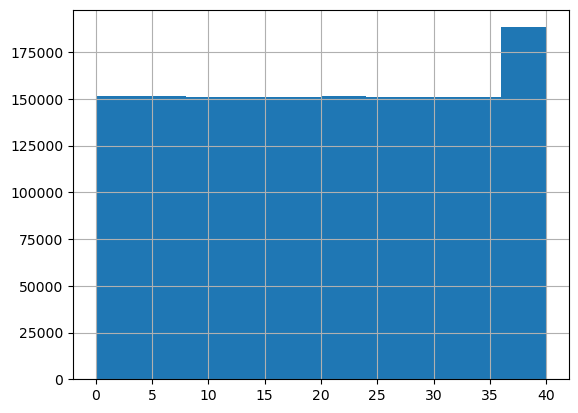

In [6]:
# Plot do histograma da variável Alvo (Quantitativa)
df['perceived_stress_score'].hist()

### Excluindo variaveis sem importância com a variável alvo

In [7]:
df.drop(columns=['app_name', 'user_id', 'blood_pressure_systolic', 'blood_pressure_diastolic', 'hobbies_count', 
                'social_events_per_month', 'books_read_per_year','volunteer_hours_per_month', 'travel_frequency_per_year', 
                 'ads_viewed_per_day', 'ads_clicked_per_day','daily_steps_count', 'followers_count','notification_response_rate',
                'urban_rural', 'last_login_date','privacy_setting_level','two_factor_auth_enabled','biometric_login_used'], inplace = True)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1547896 entries, 0 to 1547895
Data columns (total 39 columns):
 #   Column                          Non-Null Count    Dtype  
---  ------                          --------------    -----  
 0   age                             1547896 non-null  int64  
 1   gender                          1547896 non-null  object 
 2   country                         1547896 non-null  object 
 3   income_level                    1547896 non-null  object 
 4   employment_status               1547896 non-null  object 
 5   education_level                 1547896 non-null  object 
 6   relationship_status             1547896 non-null  object 
 7   has_children                    1547896 non-null  object 
 8   exercise_hours_per_week         1547896 non-null  float64
 9   sleep_hours_per_night           1547896 non-null  float64
 10  diet_quality                    1547896 non-null  object 
 11  smoking                         1547896 non-null  object 
 12  

In [9]:
# Limpando algumas variáveis, após isso irei separar as variáveis em Quantitativa e Qualitativa para conseguir analisar com maior precisão
df.drop(columns=[
    'subscription_status','uses_premium_features', 'dms_received_per_week', 'sessions_per_day', 'account_creation_year'
], inplace = True)

In [10]:
df.select_dtypes(include=['float64', 'int64']).head(5)

,age,exercise_hours_per_week,sleep_hours_per_night,perceived_stress_score,self_reported_happiness,body_mass_index,weekly_work_hours,daily_active_minutes_instagram,posts_created_per_week,reels_watched_per_day,...,comments_written_per_day,dms_sent_per_week,time_on_feed_per_day,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,following_count,average_session_length_minutes,linked_accounts_count,user_engagement_score
0,51,7.2,7.7,3,8,20.8,49.9,5.0,3,42,...,5,12,2,1,1,2,647,5.0,0,7.83
1,64,10.9,8.6,1,1,23.5,15.6,74.0,3,78,...,15,18,31,19,16,19,3511,14.8,3,1.43
2,41,5.0,6.7,4,10,28.6,31.8,5.0,7,29,...,6,12,3,1,1,1,6761,5.0,1,9.67
3,27,10.6,6.5,18,1,22.5,43.4,233.0,5,241,...,36,31,108,64,52,64,1193,25.9,1,0.94
4,55,7.7,6.8,19,1,28.1,50.2,184.0,5,146,...,36,29,78,55,22,55,1072,13.1,0,1.03


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,1547896.0,38.985440,15.294528,13.00,26.0,39.0,52.00,65.00
exercise_hours_per_week,1547896.0,7.143480,3.994556,0.00,4.0,6.6,9.70,24.10
sleep_hours_per_night,1547896.0,6.999384,1.097098,3.00,6.3,7.0,7.70,10.00
perceived_stress_score,1547896.0,19.987738,11.832578,0.00,10.0,20.0,30.00,40.00
self_reported_happiness,1547896.0,5.499804,2.871232,1.00,3.0,5.0,8.00,10.00
body_mass_index,1547896.0,25.000837,3.976188,15.00,22.3,25.0,27.70,45.00
weekly_work_hours,1547896.0,40.001454,9.997320,0.00,33.2,40.0,46.80,80.00
daily_active_minutes_instagram,1547896.0,188.229792,110.127772,5.00,101.0,186.0,271.00,580.00
posts_created_per_week,1547896.0,5.960338,3.888248,0.00,3.0,5.0,8.00,30.00
reels_watched_per_day,1547896.0,175.608146,76.220396,18.00,117.0,176.0,235.00,300.00


In [12]:
df.select_dtypes(include=['object']).head(5)

,gender,country,income_level,employment_status,education_level,relationship_status,has_children,diet_quality,smoking,alcohol_frequency,content_type_preference,preferred_content_theme
0,Female,India,High,Retired,Bachelor’s,Single,No,Good,No,Rarely,Mixed,Tech
1,Female,United Kingdom,Middle,Full-time employed,Other,Divorced,No,Very poor,No,Rarely,Photos,Fashion
2,Female,Canada,Middle,Student,Bachelor’s,In a relationship,No,Good,No,Rarely,Mixed,Other
3,Non-binary,South Korea,Middle,Unemployed,Master’s,In a relationship,No,Poor,Yes,Never,Stories,Tech
4,Male,India,Upper-middle,Full-time employed,Bachelor’s,Single,No,Average,No,Never,Videos,Food


In [13]:
df.select_dtypes(include = ['object']).describe().T

,count,unique,top,freq
gender,1547896,4,Male,743169
country,1547896,10,United States,386829
income_level,1547896,5,Middle,465037
employment_status,1547896,6,Full-time employed,695383
education_level,1547896,6,Bachelor’s,541083
relationship_status,1547896,5,Single,619236
has_children,1547896,2,No,1115158
diet_quality,1547896,5,Average,543910
smoking,1547896,3,No,1160179
alcohol_frequency,1547896,5,Rarely,541778


<h3> 2️⃣ Análise Exploratória de Acordo com o Tipo de Variável

In [14]:
# Separando as features de acordo com o tipo
var_qualitativas = df.select_dtypes(include = ['object'])

## Explorando dados Qualitativos

In [15]:
var_qualitativas.head()

,gender,country,income_level,employment_status,education_level,relationship_status,has_children,diet_quality,smoking,alcohol_frequency,content_type_preference,preferred_content_theme
0,Female,India,High,Retired,Bachelor’s,Single,No,Good,No,Rarely,Mixed,Tech
1,Female,United Kingdom,Middle,Full-time employed,Other,Divorced,No,Very poor,No,Rarely,Photos,Fashion
2,Female,Canada,Middle,Student,Bachelor’s,In a relationship,No,Good,No,Rarely,Mixed,Other
3,Non-binary,South Korea,Middle,Unemployed,Master’s,In a relationship,No,Poor,Yes,Never,Stories,Tech
4,Male,India,Upper-middle,Full-time employed,Bachelor’s,Single,No,Average,No,Never,Videos,Food


In [16]:
# Cliando função para plot
def count_plot(title, df):
    fig, axes = plt.subplots(1,1, figsize = (10,4))
    fig.suptitle(f'Distribuição da variável {title}')
    sns.countplot(data = df, x = f'{title}')

In [17]:
employment_freq = var_qualitativas['employment_status'].value_counts()
employment_freq

employment_status
Full-time employed    695383
Student               340286
Freelancer            186330
Unemployed            155499
Part-time             123784
Retired                46614
Name: count, dtype: int64

In [18]:
# representação em %
employment_freq / df.shape[0] * 100

employment_status
Full-time employed    44.924401
Student               21.983777
Freelancer            12.037630
Unemployed            10.045830
Part-time              7.996920
Retired                3.011443
Name: count, dtype: float64

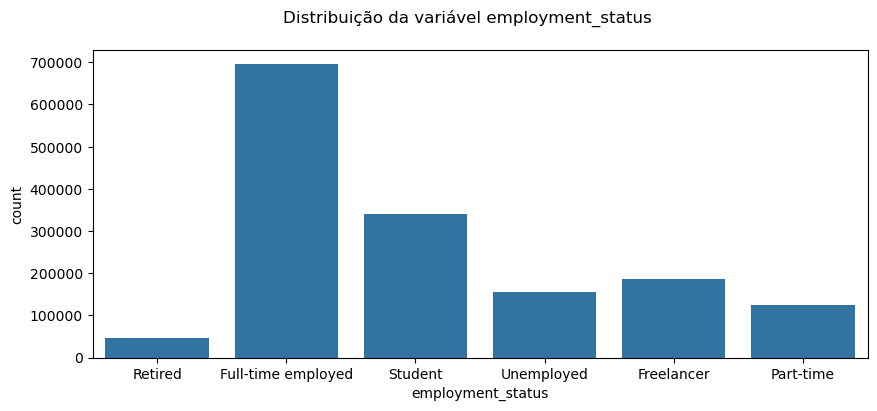

In [19]:
# Plotando a variável employment_status
employment_status = count_plot("employment_status", var_qualitativas)

In [20]:
diet_quality_freq = var_qualitativas.diet_quality.value_counts()
diet_quality_freq

diet_quality
Average      543910
Good         386255
Poor         308320
Very poor    154905
Excellent    154506
Name: count, dtype: int64

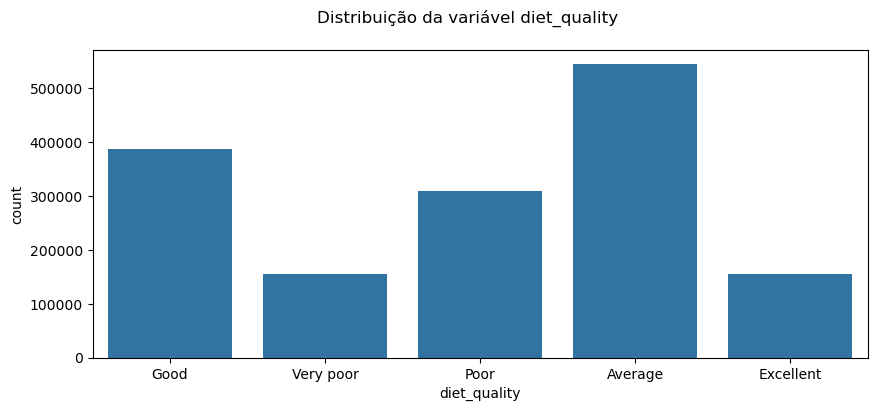

In [21]:
# Plotando a coluna diet_quality
count_plot('diet_quality', var_qualitativas)

In [22]:
freq_education_level = var_qualitativas['education_level'].value_counts()
freq_education_level

education_level
Bachelor’s      541083
High school     387323
Some college    309922
Master’s        185651
Other            77295
PhD              46622
Name: count, dtype: int64

In [23]:
# Representação em %
freq_education_level / var_qualitativas.shape[0] * 100

education_level
Bachelor’s      34.956031
High school     25.022547
Some college    20.022146
Master’s        11.993764
Other            4.993553
PhD              3.011959
Name: count, dtype: float64

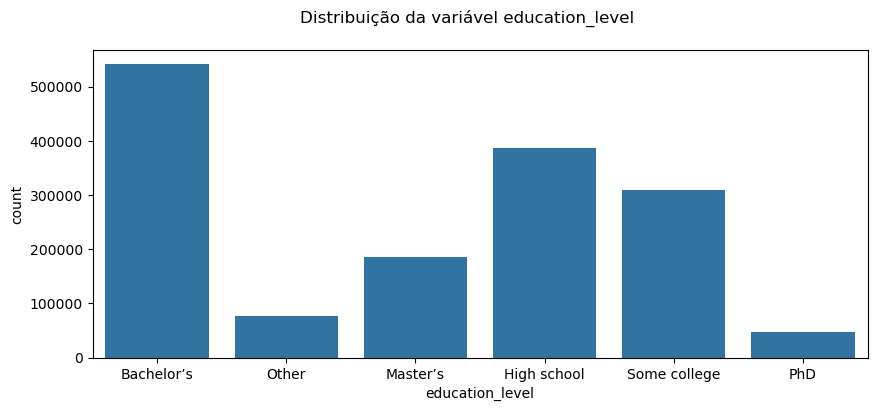

In [24]:
# Plotando a coluna education_level
count_plot('education_level', var_qualitativas)

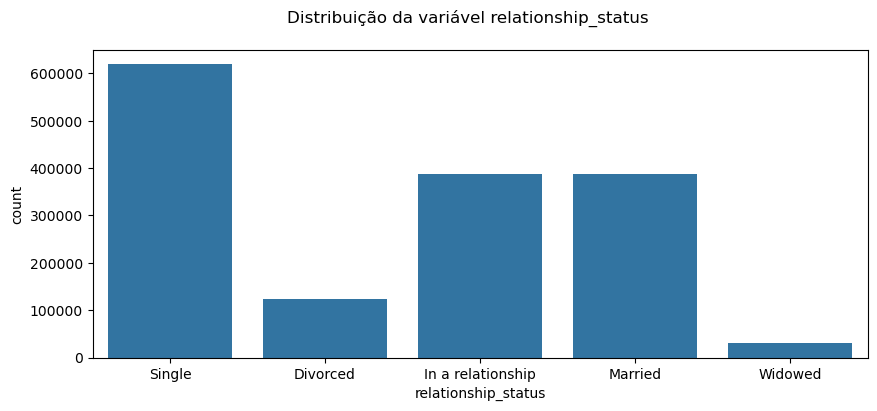

In [25]:
# Plotando a variavel relationship_status
count_plot('relationship_status', var_qualitativas)

In [26]:
# Criando tabela de Frequencia de education_level
tab_freq_relationship_status = var_qualitativas['relationship_status'].value_counts()
tab_freq_relationship_status

relationship_status
Single               619236
Married              387146
In a relationship    387085
Divorced             123591
Widowed               30838
Name: count, dtype: int64

In [27]:
tab_freq_relationship_status / var_qualitativas.shape[0] * 100

relationship_status
Single               40.005013
Married              25.011112
In a relationship    25.007171
Divorced              7.984451
Widowed               1.992253
Name: count, dtype: float64

> Devido ao número baixo de representação, linhas abaixo de 5% serão removidass evitando ruidos

In [28]:
new_df = df.copy()
new_df = new_df[(new_df['relationship_status'] != 'Widowed')]
new_df = new_df[new_df['education_level'] != 'PhD']
new_df = new_df[(new_df['employment_status'] != 'Retired')]
new_df.head()

,age,gender,country,income_level,employment_status,education_level,relationship_status,has_children,exercise_hours_per_week,sleep_hours_per_night,...,time_on_feed_per_day,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,following_count,average_session_length_minutes,content_type_preference,preferred_content_theme,linked_accounts_count,user_engagement_score
1,64,Female,United Kingdom,Middle,Full-time employed,Other,Divorced,No,10.9,8.6,...,31,19,16,19,3511,14.8,Photos,Fashion,3,1.43
2,41,Female,Canada,Middle,Student,Bachelor’s,In a relationship,No,5.0,6.7,...,3,1,1,1,6761,5.0,Mixed,Other,1,9.67
3,27,Non-binary,South Korea,Middle,Unemployed,Master’s,In a relationship,No,10.6,6.5,...,108,64,52,64,1193,25.9,Stories,Tech,1,0.94
4,55,Male,India,Upper-middle,Full-time employed,Bachelor’s,Single,No,7.7,6.8,...,78,55,22,55,1072,13.1,Videos,Food,0,1.03
5,20,Male,United States,Middle,Full-time employed,Bachelor’s,Married,Yes,5.2,5.8,...,29,6,12,13,534,16.3,Photos,Food,1,1.64


In [29]:
print(f'Número de Linhas Excluídas: {df.shape[0] - new_df.shape[0]}')

Número de Linhas Excluídas: 120877


In [30]:
new_df.drop(columns = ['gender','country'], inplace = True)
new_df

,age,income_level,employment_status,education_level,relationship_status,has_children,exercise_hours_per_week,sleep_hours_per_night,diet_quality,smoking,...,time_on_feed_per_day,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,following_count,average_session_length_minutes,content_type_preference,preferred_content_theme,linked_accounts_count,user_engagement_score
1,64,Middle,Full-time employed,Other,Divorced,No,10.9,8.6,Very poor,No,...,31,19,16,19,3511,14.8,Photos,Fashion,3,1.43
2,41,Middle,Student,Bachelor’s,In a relationship,No,5.0,6.7,Good,No,...,3,1,1,1,6761,5.0,Mixed,Other,1,9.67
3,27,Middle,Unemployed,Master’s,In a relationship,No,10.6,6.5,Poor,Yes,...,108,64,52,64,1193,25.9,Stories,Tech,1,0.94
4,55,Upper-middle,Full-time employed,Bachelor’s,Single,No,7.7,6.8,Average,No,...,78,55,22,55,1072,13.1,Videos,Food,0,1.03
5,20,Middle,Full-time employed,Bachelor’s,Married,Yes,5.2,5.8,Poor,No,...,29,6,12,13,534,16.3,Photos,Food,1,1.64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1547889,34,Lower-middle,Full-time employed,Other,In a relationship,Yes,17.3,6.4,Poor,Yes,...,75,22,15,48,1784,13.5,Live,Art,1,1.23
1547890,41,Lower-middle,Full-time employed,Master’s,Married,No,10.7,6.1,Excellent,No,...,173,44,58,149,921,26.2,Videos,Food,2,0.92
1547892,42,Lower-middle,Full-time employed,Master’s,Divorced,No,3.1,6.1,Excellent,No,...,44,9,11,26,1348,38.0,Photos,Art,1,1.32
1547893,32,Low,Full-time employed,Master’s,Single,No,4.4,6.4,Average,No,...,76,19,33,48,1891,31.8,Live,Other,5,1.01


## Explorando dados Quantitativos

In [31]:
var_quantitativas = new_df.select_dtypes(include = ['float64','int64'])

In [32]:
var_quantitativas.sample(3)

,age,exercise_hours_per_week,sleep_hours_per_night,perceived_stress_score,self_reported_happiness,body_mass_index,weekly_work_hours,daily_active_minutes_instagram,posts_created_per_week,reels_watched_per_day,...,comments_written_per_day,dms_sent_per_week,time_on_feed_per_day,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,following_count,average_session_length_minutes,linked_accounts_count,user_engagement_score
1310735,32,3.9,9.7,23,10,24.3,40.2,109.0,3,116,...,22,19,61,12,27,23,2628,36.3,2,1.21
1369954,33,4.8,6.0,37,6,23.5,33.0,331.0,9,226,...,58,35,162,98,44,90,10000,25.5,4,0.93
278114,37,2.4,5.7,6,10,23.0,46.1,5.0,2,35,...,8,8,2,1,1,1,455,5.0,2,8.67


In [33]:
var_quantitativas.corr()

,age,exercise_hours_per_week,sleep_hours_per_night,perceived_stress_score,self_reported_happiness,body_mass_index,weekly_work_hours,daily_active_minutes_instagram,posts_created_per_week,reels_watched_per_day,...,comments_written_per_day,dms_sent_per_week,time_on_feed_per_day,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,following_count,average_session_length_minutes,linked_accounts_count,user_engagement_score
age,1.000000,-0.001559,0.000966,-0.000202,0.000007,0.001222,-0.000716,-0.197861,-0.461566,-0.520546,...,-0.186274,-0.177842,-0.193097,-0.171631,-0.177313,-0.185156,-0.069717,-0.058161,0.000687,0.111813
exercise_hours_per_week,-0.001559,1.000000,0.000593,-0.000230,-0.000256,-0.000015,-0.001174,0.000089,0.001478,0.000670,...,0.000375,-0.000709,-0.000191,-0.000487,0.000249,-0.000343,-0.000936,0.001640,-0.000409,-0.001179
sleep_hours_per_night,0.000966,0.000593,1.000000,-0.001636,0.000290,0.000300,-0.000674,-0.001501,-0.000630,-0.001601,...,-0.001263,-0.001029,-0.001208,-0.002006,-0.002075,-0.001302,-0.001321,0.000835,0.000524,0.000656
perceived_stress_score,-0.000202,-0.000230,-0.001636,1.000000,0.000688,0.000211,0.000745,0.834517,0.376721,0.674714,...,0.787376,0.750189,0.813547,0.724061,0.749243,0.779540,0.057047,0.159350,-0.000493,-0.436343
self_reported_happiness,0.000007,-0.000256,0.000290,0.000688,1.000000,0.000117,-0.002278,-0.372161,-0.133677,-0.295423,...,-0.351029,-0.334299,-0.362904,-0.323050,-0.333960,-0.347913,-0.020120,-0.106419,-0.001327,0.268173
body_mass_index,0.001222,-0.000015,0.000300,0.000211,0.000117,1.000000,0.000991,-0.000388,-0.000585,-0.001046,...,-0.000407,-0.001105,-0.000148,-0.000129,-0.000531,-0.000527,-0.000333,-0.000489,-0.001031,0.000238
weekly_work_hours,-0.000716,-0.001174,-0.000674,0.000745,-0.002278,0.000991,1.000000,0.001419,0.001289,0.001669,...,0.001578,0.001156,0.001445,0.001323,0.001673,0.001003,-0.000316,0.000298,-0.000711,-0.001230
daily_active_minutes_instagram,-0.197861,0.000089,-0.001501,0.834517,-0.372161,-0.000388,0.001419,1.000000,0.505903,0.874456,...,0.942991,0.899008,0.974877,0.867819,0.897813,0.934305,0.076395,0.196669,-0.000236,-0.529962
posts_created_per_week,-0.461566,0.001478,-0.000630,0.376721,-0.133677,-0.000585,0.001289,0.505903,1.000000,0.626351,...,0.477276,0.455033,0.493291,0.438556,0.453948,0.472714,0.150738,0.075428,-0.000620,-0.161220
reels_watched_per_day,-0.520546,0.000670,-0.001601,0.674714,-0.295423,-0.001046,0.001669,0.874456,0.626351,1.000000,...,0.825162,0.786196,0.852558,0.758787,0.784990,0.817107,0.094963,0.187073,-0.000276,-0.482117


<h5><b> Filtro 1: Será removido as variáveis com baixa correlação sendo o primeiro critério:</b><p><li>Variáveis com correlação de
menores que 0.3 e menores que -0.3</b></li>
<h5><b> Filtro 2: Verificando possíveis outliers, o dataset é artificial então dificilmente irá ter, mas vale o custo de verificação</b></h5>

In [34]:
filtro_1 = var_quantitativas.corr()
filtro_1 = filtro_1[((filtro_1 >= 0.3) | (filtro_1 <= -0.3)) & (filtro_1 != 1.000)]
filtro_1 

,age,exercise_hours_per_week,sleep_hours_per_night,perceived_stress_score,self_reported_happiness,body_mass_index,weekly_work_hours,daily_active_minutes_instagram,posts_created_per_week,reels_watched_per_day,...,comments_written_per_day,dms_sent_per_week,time_on_feed_per_day,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,following_count,average_session_length_minutes,linked_accounts_count,user_engagement_score
age,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.461566,-0.520546,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
exercise_hours_per_week,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sleep_hours_per_night,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
perceived_stress_score,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.834517,0.376721,0.674714,...,0.787376,0.750189,0.813547,0.724061,0.749243,0.779540,NaN,NaN,NaN,-0.436343
self_reported_happiness,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.372161,NaN,NaN,...,-0.351029,-0.334299,-0.362904,-0.323050,-0.333960,-0.347913,NaN,NaN,NaN,NaN
body_mass_index,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weekly_work_hours,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
daily_active_minutes_instagram,NaN,NaN,NaN,0.834517,-0.372161,NaN,NaN,NaN,0.505903,0.874456,...,0.942991,0.899008,0.974877,0.867819,0.897813,0.934305,NaN,NaN,NaN,-0.529962
posts_created_per_week,-0.461566,NaN,NaN,0.376721,NaN,NaN,NaN,0.505903,NaN,0.626351,...,0.477276,0.455033,0.493291,0.438556,0.453948,0.472714,NaN,NaN,NaN,NaN
reels_watched_per_day,-0.520546,NaN,NaN,0.674714,NaN,NaN,NaN,0.874456,0.626351,NaN,...,0.825162,0.786196,0.852558,0.758787,0.784990,0.817107,NaN,NaN,NaN,-0.482117


In [35]:
new_df_final = new_df[['daily_active_minutes_instagram', 'posts_created_per_week', 'reels_watched_per_day', 'stories_viewed_per_day',
                    'likes_given_per_day','comments_written_per_day','dms_sent_per_week', 'time_on_feed_per_day', 'time_on_explore_per_day',
                    'time_on_messages_per_day', 'time_on_reels_per_day', 'perceived_stress_score']]

In [36]:
new_df_final

,daily_active_minutes_instagram,posts_created_per_week,reels_watched_per_day,stories_viewed_per_day,likes_given_per_day,comments_written_per_day,dms_sent_per_week,time_on_feed_per_day,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,perceived_stress_score
1,74.0,3,78,54,68,15,18,31,19,16,19,1
2,5.0,7,29,26,25,6,12,3,1,1,1,4
3,233.0,5,241,109,132,36,31,108,64,52,64,18
4,184.0,5,146,113,103,36,29,78,55,22,55,19
5,49.0,3,150,41,55,9,13,29,6,12,13,1
...,...,...,...,...,...,...,...,...,...,...,...,...
1547889,148.0,5,137,76,109,30,21,75,22,15,48,31
1547890,419.0,7,300,150,235,65,42,173,44,58,149,39
1547892,76.0,6,88,61,60,12,11,44,9,11,26,8
1547893,159.0,4,156,91,92,29,29,76,19,33,48,4


> 1. Será criado o primeiro modelo somente com variáveis quantitativas sem tratamento de Outliers
><br>2. O segundo modelo terá as variáveis qualitativas transformadas através de Onehotcoding
><br>3. Terceiro modelo será com as variáveis quantitativas com tratamento de Outliers
><br>4. O quarto Modelo será o segundo modelo após tratamento de Outliers e OneHotcoding

### Modelo v1

In [37]:
new_df_final.describe().T

,count,mean,std,min,25%,50%,75%,max
daily_active_minutes_instagram,1427019.0,188.239100,110.138603,5.0,101.0,186.0,271.0,580.0
posts_created_per_week,1427019.0,5.961011,3.888759,0.0,3.0,5.0,8.0,30.0
reels_watched_per_day,1427019.0,175.615135,76.221066,19.0,117.0,176.0,235.0,300.0
stories_viewed_per_day,1427019.0,101.162181,38.793313,12.0,70.0,104.0,139.0,150.0
likes_given_per_day,1427019.0,119.114267,56.154441,8.0,75.0,118.0,161.0,350.0
comments_written_per_day,1427019.0,34.214488,17.467110,0.0,20.0,33.0,47.0,80.0
dms_sent_per_week,1427019.0,28.817527,12.246455,0.0,19.0,28.0,37.0,94.0
time_on_feed_per_day,1427019.0,94.135784,56.503656,2.0,50.0,92.0,135.0,328.0
time_on_explore_per_day,1427019.0,37.623446,25.362806,1.0,18.0,34.0,53.0,171.0
time_on_messages_per_day,1427019.0,32.954696,21.448261,1.0,16.0,31.0,47.0,138.0


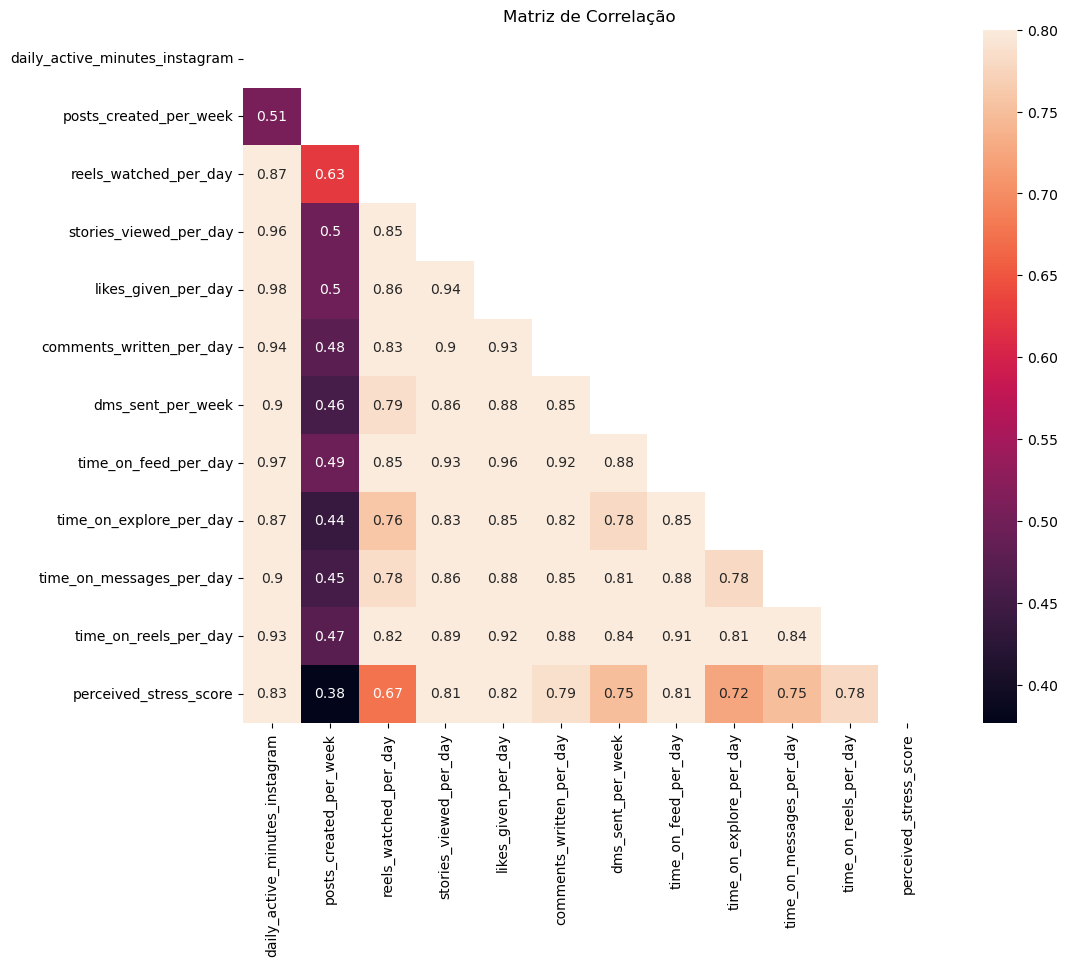

In [38]:
# Visuando as correlações por Mapa de Calor
corrmat = new_df_final.corr()
fig = plt.figure(figsize = (12,9))
mask = np.triu(np.ones_like(corrmat, dtype = bool))
sns.heatmap(corrmat, vmax = .8, mask = mask, square = True, annot = True)
plt.title("Matriz de Correlação")
plt.show()

In [39]:
new_df_final.head()

,daily_active_minutes_instagram,posts_created_per_week,reels_watched_per_day,stories_viewed_per_day,likes_given_per_day,comments_written_per_day,dms_sent_per_week,time_on_feed_per_day,time_on_explore_per_day,time_on_messages_per_day,time_on_reels_per_day,perceived_stress_score
1,74.0,3,78,54,68,15,18,31,19,16,19,1
2,5.0,7,29,26,25,6,12,3,1,1,1,4
3,233.0,5,241,109,132,36,31,108,64,52,64,18
4,184.0,5,146,113,103,36,29,78,55,22,55,19
5,49.0,3,150,41,55,9,13,29,6,12,13,1


In [40]:
# Etapa 1: Preparação dos dados
target = 'perceived_stress_score'
X = new_df_final.drop(columns= [target])
y = new_df_final[target]

In [41]:
# Etapa 3: Sepração Treino/Teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

In [42]:
# Devido ao modelo de Regressão Linear ser sensível as variações de dados, vamos aplicar uma técnica de padronização
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [43]:
# Etapa 4: Importar e treinar o modelo
modelo_v1 = LinearRegression()
modelo_v1.fit(X_train, y_train)

LinearRegression()

In [44]:
# Etapa 5: Avaliar modelo
pred = modelo_v1.predict(X_test)

In [45]:
print("R2: ", r2_score(y_test, pred))
print("RMSE: ", np.sqrt(mean_squared_error(y_test, pred)))

R2:  0.714291430815495
RMSE:  6.324829579897799


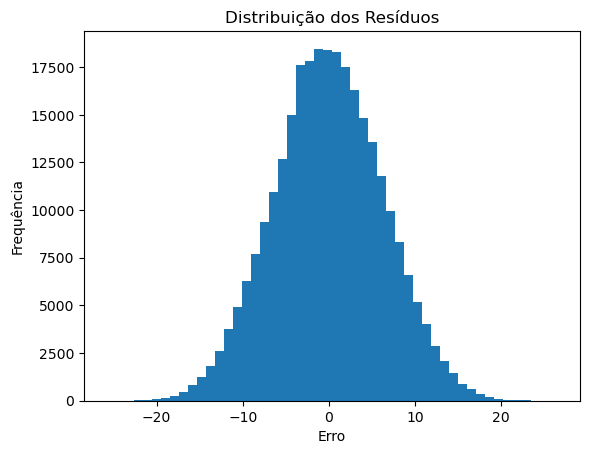

In [171]:
residual = y_test - pred

plt.figure()
plt.hist(residual, bins=50)
plt.title("Distribuição dos Resíduos")
plt.xlabel("Erro")
plt.ylabel("Frequência")
plt.show()

## Modelagem Estatística

### Modelo_V2

In [46]:
variaveis_modelagem = new_df_final.drop(columns=['perceived_stress_score'])
variaveis_modelagem = variaveis_modelagem.columns
variaveis_modelagem

Index(['daily_active_minutes_instagram', 'posts_created_per_week',
       'reels_watched_per_day', 'stories_viewed_per_day',
       'likes_given_per_day', 'comments_written_per_day', 'dms_sent_per_week',
       'time_on_feed_per_day', 'time_on_explore_per_day',
       'time_on_messages_per_day', 'time_on_reels_per_day'],
      dtype='object')

In [47]:
# Variável alvo x variaveis preditoras
formula = 'perceived_stress_score ~ daily_active_minutes_instagram+ posts_created_per_week+reels_watched_per_day+stories_viewed_per_day+ \
likes_given_per_day + comments_written_per_day +dms_sent_per_week+time_on_feed_per_day+time_on_explore_per_day+time_on_messages_per_day+time_on_reels_per_day'

In [48]:
# Cria e treina modelo
modelo_v2 = ols(formula, data = new_df_final).fit()

In [49]:
# Coeficiente de determinação
print(f'R-squared: {modelo_v2.rsquared}')

R-squared: 0.7140447946741996


In [50]:
# Coeficientes
print(f'R-squared: {modelo_v2.params}')

R-squared: Intercept                         2.768972
daily_active_minutes_instagram    0.088530
posts_created_per_week           -0.013971
reels_watched_per_day            -0.038039
stories_viewed_per_day            0.071392
likes_given_per_day               0.000522
comments_written_per_day          0.001832
dms_sent_per_week                -0.000211
time_on_feed_per_day              0.000117
time_on_explore_per_day          -0.000292
time_on_messages_per_day         -0.000027
time_on_reels_per_day            -0.000435
dtype: float64


In [51]:
modelo_v2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     perceived_stress_score   R-squared:                       0.714
Model:                                OLS   Adj. R-squared:                  0.714
Method:                     Least Squares   F-statistic:                 3.239e+05
Date:                    Mon, 23 Feb 2026   Prob (F-statistic):               0.00
Time:                            07:03:35   Log-Likelihood:            -4.6576e+06
No. Observations:                 1427019   AIC:                         9.315e+06
Df Residuals:                     1427007   BIC:                         9.315e+06
Df Model:                              11                                         
Covariance Type:                nonrobust                                         
==================================================================================================
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept                          2.7690      0.027    101.919      0.000       2.716       2.822
daily_active_minutes_instagram     0.0885      0.000    200.353      0.000       0.088       0.089
posts_created_per_week            -0.0140      0.002     -7.946      0.000      -0.017      -0.011
reels_watched_per_day             -0.0380      0.000   -237.509      0.000      -0.038      -0.038
stories_viewed_per_day             0.0714      0.000    153.832      0.000       0.070       0.072
likes_given_per_day                0.0005      0.000      1.075      0.282      -0.000       0.001
comments_written_per_day           0.0018      0.001      2.010      0.044     4.6e-05       0.004
dms_sent_per_week                 -0.0002      0.001     -0.214      0.831      -0.002       0.002
time_on_feed_per_day               0.0001      0.000      0.278      0.781      -0.001       0.001
time_on_explore_per_day           -0.0003      0.000     -0.696      0.487      -0.001       0.001
time_on_messages_per_day       -2.749e-05      0.001     -0.049      0.961      -0.001       0.001
time_on_reels_per_day             -0.0004      0.000     -1.036      0.300      -0.001       0.000
==============================================================================
Omnibus:                     1571.038   Durbin-Watson:                   1.999
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1350.656
Skew:                           0.014   Prob(JB):                    5.11e-294
Kurtosis:                       2.852   Cond. No.                     1.87e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.87e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Devido ao P>|t| Alto de algumas variáveis demonstrando multicolinearidade, vamos excluir aquelas com o maior indicador. Porém devido a interação de algumas variáveis,
será mantida a variável 'time_on_reels_per_day', por a manter a precisão do modelo com 70% e apresentar melhor desempenho.


### Modelo v3

In [102]:
# Variável alvo x variaveis preditoras
formula_3 = 'perceived_stress_score ~ posts_created_per_week+reels_watched_per_day+stories_viewed_per_day+comments_written_per_day+likes_given_per_day+time_on_reels_per_day'

In [103]:
# Cria e treina modelo
modelo_v3 = ols(formula_3, data = new_df_final).fit()

In [104]:
# Coeficiente de determinação
print(f'R-squared: {modelo_v3.rsquared}')

R-squared: 0.7014557149670708


<p>Exluindo 5 variáveis, conseguimos manter um número próximo do modelo_v1, onde aproximadamente 70% da variabilidade de score_stess
pode ser explicada através das variráveis independentes do modelo.
Um valor bastante alto, sugerindo que os ajustes foram bem feitos</p>

In [105]:
# Coeficientes
print(f'R-squared: {modelo_v3.params}')

R-squared: Intercept                  -1.808524
posts_created_per_week     -0.029278
reels_watched_per_day      -0.030148
stories_viewed_per_day      0.119405
comments_written_per_day    0.088627
likes_given_per_day         0.084380
time_on_reels_per_day       0.037202
dtype: float64


In [106]:
modelo_v3.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     perceived_stress_score   R-squared:                       0.701
Model:                                OLS   Adj. R-squared:                  0.701
Method:                     Least Squares   F-statistic:                 5.588e+05
Date:                    Mon, 23 Feb 2026   Prob (F-statistic):               0.00
Time:                            10:18:10   Log-Likelihood:            -4.6884e+06
No. Observations:                 1427019   AIC:                         9.377e+06
Df Residuals:                     1427012   BIC:                         9.377e+06
Df Model:                               6                                         
Covariance Type:                nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   -1.8085      0.018   -100.904      0.000      -1.844      -1.773
posts_created_per_week      -0.0293      0.002    -16.307      0.000      -0.033      -0.026
reels_watched_per_day       -0.0301      0.000   -187.898      0.000      -0.030      -0.030
stories_viewed_per_day       0.1194      0.000    276.453      0.000       0.119       0.120
comments_written_per_day     0.0886      0.001    102.904      0.000       0.087       0.090
likes_given_per_day          0.0844      0.000    234.718      0.000       0.084       0.085
time_on_reels_per_day        0.0372      0.000     92.727      0.000       0.036       0.038
==============================================================================
Omnibus:                      956.768   Durbin-Watson:                   1.999
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              886.189
Skew:                          -0.033   Prob(JB):                    3.69e-193
Kurtosis:                       2.897   Cond. No.                         879.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [110]:
var_quantitativas2 = df.select_dtypes(['int64', 'float64'])

In [113]:
[x for x in var_quantitativas2.columns]

['age',
 'exercise_hours_per_week',
 'sleep_hours_per_night',
 'perceived_stress_score',
 'self_reported_happiness',
 'body_mass_index',
 'weekly_work_hours',
 'daily_active_minutes_instagram',
 'posts_created_per_week',
 'reels_watched_per_day',
 'stories_viewed_per_day',
 'likes_given_per_day',
 'comments_written_per_day',
 'dms_sent_per_week',
 'time_on_feed_per_day',
 'time_on_explore_per_day',
 'time_on_messages_per_day',
 'time_on_reels_per_day',
 'following_count',
 'average_session_length_minutes',
 'linked_accounts_count',
 'user_engagement_score']

In [143]:
# Variável alvo x variaveis preditoras
formula_4 = 'perceived_stress_score ~ posts_created_per_week+reels_watched_per_day+stories_viewed_per_day+comments_written_per_day+likes_given_per_day+time_on_reels_per_day'

In [144]:
# Treinar modelo
modelo_v4 = ols(formula_4, data = var_quantitativas2).fit()

In [145]:
# Coeficientes
print(f'R2: {modelo_v4.rsquared}')

R2: 0.7014606776772314


In [146]:
modelo_v4.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                              
==================================================================================
Dep. Variable:     perceived_stress_score   R-squared:                       0.701
Model:                                OLS   Adj. R-squared:                  0.701
Method:                     Least Squares   F-statistic:                 6.062e+05
Date:                    Mon, 23 Feb 2026   Prob (F-statistic):               0.00
Time:                            10:32:38   Log-Likelihood:            -5.0854e+06
No. Observations:                 1547896   AIC:                         1.017e+07
Df Residuals:                     1547889   BIC:                         1.017e+07
Df Model:                               6                                         
Covariance Type:                nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                   -1.8111      0.017   -105.240      0.000      -1.845      -1.777
posts_created_per_week      -0.0289      0.002    -16.791      0.000      -0.032      -0.026
reels_watched_per_day       -0.0301      0.000   -195.541      0.000      -0.030      -0.030
stories_viewed_per_day       0.1194      0.000    287.901      0.000       0.119       0.120
comments_written_per_day     0.0887      0.001    107.263      0.000       0.087       0.090
likes_given_per_day          0.0843      0.000    244.275      0.000       0.084       0.085
time_on_reels_per_day        0.0371      0.000     96.356      0.000       0.036       0.038
==============================================================================
Omnibus:                     1046.844   Durbin-Watson:                   2.000
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              968.472
Skew:                          -0.033   Prob(JB):                    5.00e-211
Kurtosis:                       2.896   Cond. No.                         879.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""